# Tokenized World Model — Visual Experiments

> **Goal:** Watch an observation become a token sequence, then watch a next-token model imagine the future — dynamics as language modelling.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Frame → tokens** | What does it mean to encode a frame as a grid of discrete tokens? |
| 2 | **Next-token imagination** | Can an autoregressive token model roll out a plausible future? |
| 3 | **Compounding error** | How does rollout error grow with the imagination horizon? |
| 4 | **Multimodal futures** | Why does a categorical next-token head beat a Gaussian when the future branches? |

---
**Linked theory:** [research/07-tokenized-world-model.md](../research/07-tokenized-world-model.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


---
## Experiment 1: Frame → tokens

**Question:** A tokenized world model first runs every observation through a discrete autoencoder. What does "a frame is a sequence of K tokens from a vocabulary of N" look like concretely?

We render a small grid-world frame (a bright object on a background), split it into patches, and quantize each patch with a tiny learned codebook — turning the image into a grid of token ids.

In [2]:
np.random.seed(1)

FR = 24          # frame size in pixels
P = 4            # patch size
G = FR // P      # patches per side


def render(cx, cy, size=FR):
    yy, xx = np.mgrid[0:size, 0:size]
    blob = np.exp(-(((xx - cx) ** 2 + (yy - cy) ** 2) / 6.0))
    return np.clip(blob, 0, 1)


def patchify(frame):
    return frame.reshape(G, P, G, P).transpose(0, 2, 1, 3).reshape(G * G, P * P)


# build a tokenizer codebook from many frames at random object positions
patches = np.concatenate([patchify(render(*np.random.randint(3, FR - 3, 2))) for _ in range(300)])
N = 8   # vocabulary size
tokenizer = KMeans(n_clusters=N, n_init=4, random_state=0).fit(patches)

frame = render(16, 9)
tok = tokenizer.predict(patchify(frame)).reshape(G, G)
recon = tokenizer.cluster_centers_[tok.ravel()].reshape(G, G, P, P).transpose(0, 2, 1, 3).reshape(FR, FR)
print(f'frame {FR}x{FR} -> {G}x{G} = {G*G} tokens, vocabulary N={N}')
print('flattened token sequence:', tok.ravel())

frame 24x24 -> 6x6 = 36 tokens, vocabulary N=8
flattened token sequence: [0 0 0 0 0 0 0 0 0 0 5 0 0 0 0 7 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


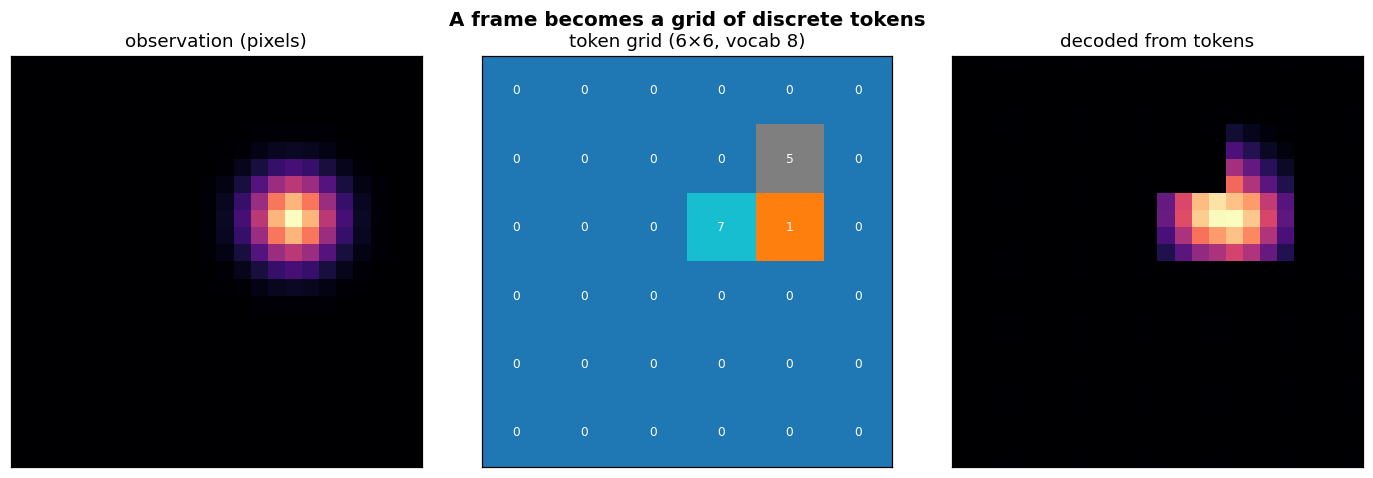

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
fig.suptitle('A frame becomes a grid of discrete tokens', fontsize=13, fontweight='bold')

axes[0].imshow(frame, cmap='magma')
axes[0].set_title('observation (pixels)')
axes[0].set_xticks([]); axes[0].set_yticks([])

im = axes[1].imshow(tok, cmap='tab10', vmin=0, vmax=N - 1)
axes[1].set_title(f'token grid ({G}×{G}, vocab {N})')
for (i, j), v in np.ndenumerate(tok):
    axes[1].text(j, i, str(v), ha='center', va='center', fontsize=8, color='white')
axes[1].set_xticks([]); axes[1].set_yticks([])

axes[2].imshow(recon, cmap='magma')
axes[2].set_title('decoded from tokens')
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The pixel frame (left) becomes a 6×6 grid of integer ids (middle), most of them the same "background" token with a few distinct tokens where the object sits. Decoding the tokens (right) recovers the frame approximately.
2. **Why it looks this way:** The discrete autoencoder maps each patch to its nearest codeword, so visually similar patches (all the empty background) collapse to one token. The image is now literally a sequence of 36 symbols drawn from an 8-word vocabulary.
3. **Key takeaway:** This is the bridge of Tier 9 — once a frame is a token sequence, predicting the next frame is the same shape of problem as predicting the next word.

---
## Experiment 2: Next-token imagination

**Question:** Once states are tokens, dynamics is just $p(\text{token}_{t+1}\mid \text{token}_t, a_t)$. Can a model learned by counting transitions roll out a coherent imagined future?

We use a grid-world where the object's cell is a single token. A 'world model' learns the transition table from random-policy data, then imagines a trajectory under a chosen action sequence — a discrete analogue of latent imagination.

In [4]:
np.random.seed(2)

GZ = 8                       # grid is GZ x GZ cells
ACTIONS = {0: (0, 1), 1: (0, -1), 2: (1, 0), 3: (-1, 0)}   # R, L, D, U


def step(cell, a, slip=0.0, rng=np.random):
    x, y = divmod(cell, GZ)
    dx, dy = ACTIONS[a]
    if rng.random() < slip:                      # slip = perpendicular move
        dx, dy = (dy, dx) if rng.random() < 0.5 else (-dy, -dx)
    x = min(max(x + dx, 0), GZ - 1)
    y = min(max(y + dy, 0), GZ - 1)
    return x * GZ + y


# learn transition model from random-policy data (deterministic world here)
model = defaultdict(Counter)
rng = np.random.default_rng(0)
cell = rng.integers(0, GZ * GZ)
for _ in range(20000):
    a = rng.integers(0, 4)
    nxt = step(cell, a, slip=0.0, rng=rng)
    model[(cell, a)][nxt] += 1
    cell = nxt


def predict(cell, a):
    return model[(cell, a)].most_common(1)[0][0]


# imagine a trajectory and compare to the true world
start = 1 * GZ + 1
plan = [0, 0, 2, 2, 0, 2, 1, 2, 0, 0]
imag, true = [start], [start]
ci, ct = start, start
for a in plan:
    ci = predict(ci, a); imag.append(ci)
    ct = step(ct, a, slip=0.0); true.append(ct)
print('imagined cells:', imag)
print('true     cells:', true)

imagined cells:

 [9, np.int64(10), np.int64(11), np.int64(19), np.int64(27), np.int64(28), np.int64(36), np.int64(35), np.int64(43), np.int64(44), np.int64(45)]
true     cells: [9, 10, 11, 19, 27, 28, 36, 35, 43, 44, 45]


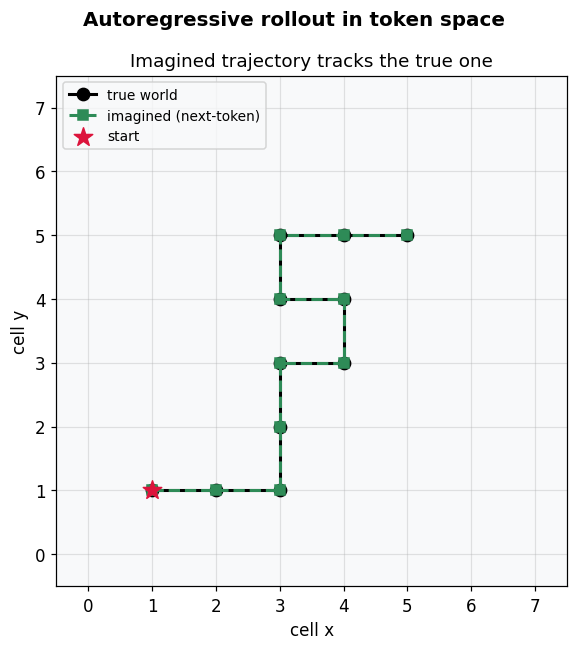

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 6))
fig.suptitle('Autoregressive rollout in token space', fontsize=13, fontweight='bold')

to_xy = lambda c: (divmod(c, GZ)[1], divmod(c, GZ)[0])
tx = np.array([to_xy(c) for c in true])
ix = np.array([to_xy(c) for c in imag])
ax.plot(tx[:, 0], tx[:, 1], '-o', color='black', lw=2, ms=8, label='true world')
ax.plot(ix[:, 0], ix[:, 1], '--s', color='seagreen', lw=2, ms=6, label='imagined (next-token)')
ax.scatter(*to_xy(start), c='crimson', s=160, marker='*', zorder=5, label='start')
ax.set_xticks(range(GZ)); ax.set_yticks(range(GZ))
ax.set_xlim(-0.5, GZ - 0.5); ax.set_ylim(-0.5, GZ - 0.5)
ax.set_xlabel('cell x'); ax.set_ylabel('cell y')
ax.set_title('Imagined trajectory tracks the true one')
ax.legend(loc='upper left', fontsize=9); ax.set_aspect('equal')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Starting from the red star, the imagined green path (the model's next-token predictions chained together) lands exactly on the black true path produced by the real environment under the same actions.
2. **Why it looks this way:** With enough data on a deterministic world, the learned transition table captures $p(\text{token}_{t+1}\mid \text{token}_t,a_t)$ correctly, so autoregressively feeding predictions back gives a faithful rollout — the agent can plan entirely 'in imagination'.
3. **Key takeaway:** Rollout is just autoregressive generation: predict next token, append, repeat. This is exactly how a Transformer world model imagines futures, only with a learned net instead of a count table.

---
## Experiment 3: Compounding error

**Question:** Real worlds are stochastic and models are imperfect. How does the gap between imagination and reality grow as the rollout gets longer?

We add slip noise to the world and let the (deterministic, most-likely) model imagine long rollouts, measuring the cell-distance between imagined and true positions versus horizon.

In [6]:
np.random.seed(3)

H = 30
n_traj = 400
slip = 0.2
errs = np.zeros((n_traj, H))
rng = np.random.default_rng(5)
for k in range(n_traj):
    ci = ct = rng.integers(0, GZ * GZ)
    actions = rng.integers(0, 4, H)
    for h, a in enumerate(actions):
        ci = predict(ci, a)                 # model imagines (deterministic)
        ct = step(ct, a, slip=slip, rng=rng)  # reality slips
        xi, yi = divmod(ci, GZ); xt, yt = divmod(ct, GZ)
        errs[k, h] = abs(xi - xt) + abs(yi - yt)
mean_err = errs.mean(0)
print('error at horizon 1, 10, 30:', np.round(mean_err[[0, 9, 29]], 2))

error at horizon 1, 10, 30: [0.38 1.54 2.14]


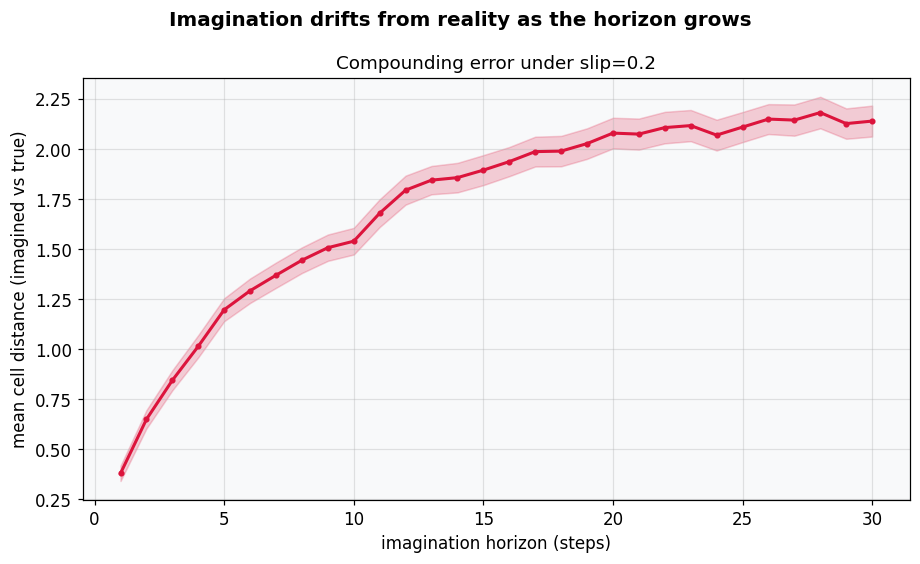

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
fig.suptitle('Imagination drifts from reality as the horizon grows', fontsize=13, fontweight='bold')

ax.plot(range(1, H + 1), mean_err, '-o', ms=3, color='crimson', lw=2)
ax.fill_between(range(1, H + 1), mean_err - errs.std(0) / np.sqrt(n_traj),
                mean_err + errs.std(0) / np.sqrt(n_traj), color='crimson', alpha=0.2)
ax.set_xlabel('imagination horizon (steps)'); ax.set_ylabel('mean cell distance (imagined vs true)')
ax.set_title(f'Compounding error under slip={slip}')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The mean distance between imagined and true position climbs steadily with horizon, fast at first then leveling as it approaches the grid's diameter (the worst possible distance).
2. **Why it looks this way:** Each stochastic slip the model cannot foresee adds a small error; because each prediction feeds the next, those errors accumulate and the imagined and true trajectories diverge — the compounding-error problem of all autoregressive rollouts.
3. **Key takeaway:** Token world models are reliable for short horizons but drift over long ones, which is why imagination horizon is a key hyperparameter and why richer models predict distributions, not single tokens.

---
## Experiment 4: Multimodal futures

**Question:** When the future genuinely branches, a categorical next-token head can put mass on each outcome. A continuous Gaussian head must pick a mean. What goes wrong for the Gaussian?

From a centre cell on a line, the object jumps left or right by 3 with equal probability — never staying put. We compare the empirical categorical distribution to a fitted Gaussian.

In [8]:
np.random.seed(4)

n_cells = 21
centre = 10
samples = centre + np.where(np.random.rand(20000) < 0.5, -3, 3)
cat = np.bincount(samples, minlength=n_cells) / len(samples)
mu, sigma = samples.mean(), samples.std()
xs = np.arange(n_cells)
gauss = np.exp(-0.5 * ((xs - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
print(f'true next cells: {{{centre-3}, {centre+3}}} each 50%')
print(f'Gaussian fit: mean={mu:.1f} (the centre cell, which NEVER occurs), std={sigma:.1f}')

true next cells: {7, 13} each 50%
Gaussian fit: mean=10.0 (the centre cell, which NEVER occurs), std=3.0


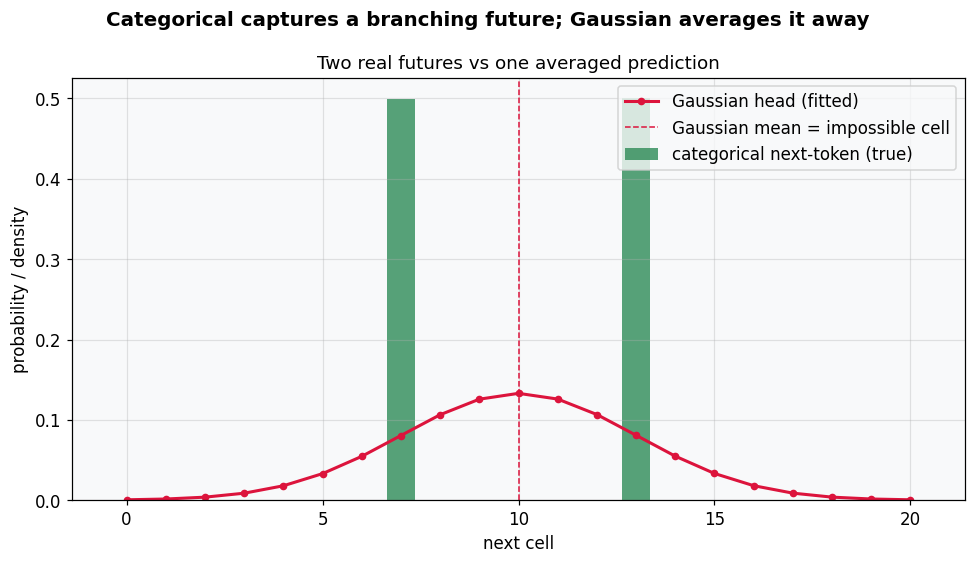

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.2))
fig.suptitle('Categorical captures a branching future; Gaussian averages it away', fontsize=13, fontweight='bold')

ax.bar(xs, cat, width=0.7, color='seagreen', alpha=0.8, label='categorical next-token (true)')
ax.plot(xs, gauss, '-o', color='crimson', lw=2, ms=4, label='Gaussian head (fitted)')
ax.axvline(mu, color='crimson', ls='--', lw=1, label='Gaussian mean = impossible cell')
ax.set_xlabel('next cell'); ax.set_ylabel('probability / density')
ax.set_title('Two real futures vs one averaged prediction')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The green categorical distribution has two clean spikes at cells 7 and 13 — the two real outcomes. The red Gaussian piles its mass on cell 10, the midpoint, which is an outcome that never actually happens.
2. **Why it looks this way:** A unimodal Gaussian can only represent one centre, so faced with a 50/50 branch it lands in the middle. The categorical distribution over tokens has a free parameter per outcome, so it represents both modes exactly.
3. **Key takeaway:** Discrete token heads handle multimodal, branching futures naturally — the reason DreamerV2 moved to discrete latents and why tokenized world models avoid the blurry 'average future' of continuous heads.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Frame → tokens | A discrete autoencoder turns an image into a grid of vocabulary symbols — an observation becomes a sentence. |
| 2. Next-token imagination | Dynamics is $p(\text{token}_{t+1}\mid\text{token}_t,a_t)$; autoregressive rollout imagines coherent futures. |
| 3. Compounding error | Unforeseen stochasticity accumulates over the rollout, so imagination drifts from reality with horizon. |
| 4. Multimodal futures | A categorical token head represents branching futures exactly; a Gaussian collapses them to an impossible mean. |

### Connection to the broader theory

Tokenized world models cash in everything Tier 9 built: a [VQ](../research/01-vector-quantization.md) or [FSQ](../research/06-finite-scalar-quantization.md) tokenizer plus an autoregressive Transformer turns [latent transitions](../../06-latent-temporal/research/02-latent-transition-model.md) into next-token prediction, inheriting the entire language-model toolbox. The final two topics scale this pattern to real systems: **GAIA-1** for autonomous driving and **Genie** for interactive world generation from video.